In [2]:
import torch
from PIL import Image
from torchvision import transforms, models
import torch.nn as nn
import os

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to build the model (same as in the notebook)
def build_model(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

# Load the saved checkpoint
CKPT_PATH = "outputs_pytorch/best_model.pt"  # Adjust path if needed
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    CLASS_NAMES = ckpt["classes"]
    IMG_SIZE = ckpt["img_size"]
    num_classes = len(CLASS_NAMES)
    
    # Build the model and load state dict
    model = build_model(num_classes)
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE)
    print(f"Loaded model from: {CKPT_PATH}")
else:
    raise FileNotFoundError(f"Checkpoint not found at {CKPT_PATH}")

# Prediction function (adapted from the notebook)
def predict_image(image_path, topk=3):
    model.eval()  # Set model to evaluation mode

    # Image transformations (same as eval_tfms in the notebook)
    H, W = IMG_SIZE[1], IMG_SIZE[0]
    tfm = transforms.Compose([
        transforms.Resize((H, W)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # Load and preprocess the image
    img = Image.open(image_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    # Get top-k predictions
    idxs = probs.argsort()[-topk:][::-1]
    return [(CLASS_NAMES[i], float(probs[i])) for i in idxs]

# Example usage
image_path = r"data_merged\test\pituitary\2fc97fcdbb74907e1f32a2ee95a97353a26c40076a53628a530f738f3292a1ee.jpg"  # Replace with your image path
result = predict_image(image_path)

# Print results
print("Top Predictions:")
for i, (label, prob) in enumerate(result, 1):
    print(f"{i}. {label.capitalize():<15} - {prob * 100:.2f}%")

Loaded model from: outputs_pytorch/best_model.pt
Top Predictions:
1. Pituitary       - 100.00%
2. Meningioma      - 0.00%
3. No_tumor        - 0.00%


In [ ]:
import torch
from PIL import Image
from torchvision import transforms, models
import torch.nn as nn
import os

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to build the model
def build_model(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

# Load the saved checkpoint
CKPT_PATH = "outputs_pytorch/best_model.pt"
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    CLASS_NAMES = ckpt["classes"]
    IMG_SIZE = ckpt["img_size"]
    num_classes = len(CLASS_NAMES)
    
    model = build_model(num_classes)
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE)
    print(f"Loaded model from: {CKPT_PATH}")
else:
    raise FileNotFoundError(f"Checkpoint not found at {CKPT_PATH}")

# Prediction function
def predict_image(image_path, topk=1):  # Changed topk to 1 for single output
    model.eval()
    H, W = IMG_SIZE[1], IMG_SIZE[0]
    tfm = transforms.Compose([
        transforms.Resize((H, W)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    idx = probs.argmax()  # Get index of highest probability
    return CLASS_NAMES[idx], float(probs[idx])

# Example usage
image_path = r"C:\Users\pavan\OneDrive\Documents\jhj.jpg"
label, prob = predict_image(image_path)
print(f"Prediction: {label.capitalize():<15} - {prob * 100:.2f}%")

Loaded model from: outputs_pytorch/best_model.pt
Prediction: Pituitary       - 99.68%


In [1]:
import torch
from PIL import Image
from torchvision import transforms, models
import torch.nn as nn
import os

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to build the model
def build_model(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

# Load the saved checkpoint
CKPT_PATH = "outputs_pytorch/best_model.pt"
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    CLASS_NAMES = ckpt["classes"]
    IMG_SIZE = ckpt["img_size"]
    num_classes = len(CLASS_NAMES)
    
    model = build_model(num_classes)
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE)
    print(f"Loaded model from: {CKPT_PATH}")
else:
    raise FileNotFoundError(f"Checkpoint not found at {CKPT_PATH}")

# Prediction function
def predict_image(image_path, topk=1):  # Changed topk to 1 for single output
    model.eval()
    H, W = IMG_SIZE[1], IMG_SIZE[0]
    tfm = transforms.Compose([
        transforms.Resize((H, W)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    idx = probs.argmax()  # Get index of highest probability
    return CLASS_NAMES[idx], float(probs[idx])

# Example usage
image_path = r"data_merged\test\meningioma\3ad594cf65b88442c7764f0f011fd1cde59f92cf8c8c6c5c716119f85a7445db.jpg"
label, prob = predict_image(image_path)
print(f"Prediction: {label.capitalize():<15} - {prob * 100:.2f}%")

Loaded model from: outputs_pytorch/best_model.pt
Prediction: Meningioma      - 100.00%


In [12]:
import tkinter as tk
from tkinter import filedialog, Label, Button
from PIL import Image, ImageTk
import torch
from torchvision import transforms, models
import torch.nn as nn
import os

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to build the model
def build_model(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

# Load the saved checkpoint
CKPT_PATH = "outputs_pytorch/best_model.pt"
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    CLASS_NAMES = ckpt["classes"]
    IMG_SIZE = ckpt["img_size"]
    num_classes = len(CLASS_NAMES)
    
    model = build_model(num_classes)
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE)
    model.eval()  # Set to evaluation mode
    print(f"Loaded model from: {CKPT_PATH}")
else:
    raise FileNotFoundError(f"Checkpoint not found at {CKPT_PATH}")

# Prediction function
def predict_image(image_path):
    H, W = IMG_SIZE[1], IMG_SIZE[0]
    tfm = transforms.Compose([
        transforms.Resize((H, W)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    idx = probs.argmax()
    return CLASS_NAMES[idx], float(probs[idx])

# Global variables for image handling
image_path = None
image_label = None
result_label = None
display_img = None  # To keep reference to PhotoImage

def upload_image():
    global image_path, display_img
    filetypes = [("Image files", "*.png;*.jpg;*.jpeg;*.gif;*.bmp")]
    path = filedialog.askopenfilename(filetypes=filetypes)
    if path:
        image_path = path
        img = Image.open(path).convert("RGB")
        img = img.resize((300, 300))  # Resize for display
        display_img = ImageTk.PhotoImage(img)
        image_label.config(image=display_img)
        image_label.image = display_img  # Keep reference
        result_label.config(text="Image uploaded. Click 'Analyze' to process.")
    else:
        result_label.config(text="No image selected.")

def analyze_image():
    global image_path, display_img
    if not image_path:
        result_label.config(text="Please upload an image first.")
        return
    
    label, prob = predict_image(image_path)
    result_text = f"Predicted Category: {label.capitalize()} - Confidence: {prob * 100:.2f}%"
    result_label.config(text=result_text)
    
    if label != 'no_tumor':
        # Add red border to simulate tumor region highlight
        img = Image.open(image_path).convert("RGB")
        img = img.resize((300, 300))  # Resize for display
        border_size = 10
        bordered_img = Image.new('RGB', (img.width + 2 * border_size, img.height + 2 * border_size), 'red')
        bordered_img.paste(img, (border_size, border_size))
        display_img = ImageTk.PhotoImage(bordered_img)
        image_label.config(image=display_img)
        image_label.image = display_img  # Update reference

# Create the main window
root = tk.Tk()
root.title("Tumor Classification GUI")
root.geometry("400x500")

# Upload button
upload_btn = Button(root, text="Select Image", command=upload_image)
upload_btn.pack(pady=10)

# Image display label
image_label = Label(root)
image_label.pack(pady=10)

# Analyze button
analyze_btn = Button(root, text="Analyze", command=analyze_image)
analyze_btn.pack(pady=10)

# Result label
result_label = Label(root, text="Upload an image to start.")
result_label.pack(pady=10)

# Start the GUI loop
root.mainloop()

Loaded model from: outputs_pytorch/best_model.pt


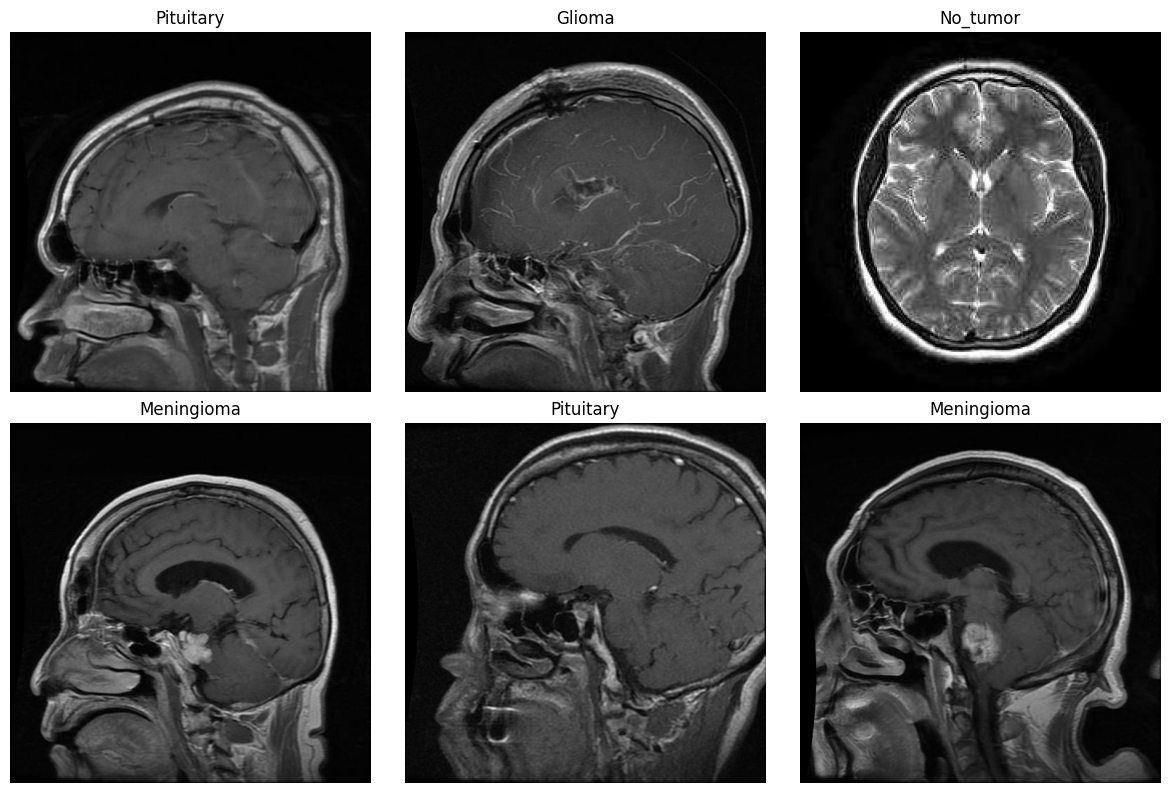

In [4]:
import matplotlib.pyplot as plt

# Plot 6 images with predictions
plt.figure(figsize=(12, 8))

for idx, image_path in enumerate(image_paths):
    result = predict_image(image_path, topk=1)  
    
    # Ensure we get (label, prob) correctly
    first_result = result[0]
    if isinstance(first_result, (list, tuple)) and len(first_result) == 2:
        pred_label, pred_prob = first_result
    else:
        pred_label, pred_prob = str(first_result), 0.0  # fallback
    
    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{pred_label.capitalize()}")

plt.tight_layout()
plt.show()


In [5]:
import matplotlib.pyplot as plt

# Check what keys are in checkpoint
print("Available keys:", ckpt.keys())

# If loss and accuracy history exist in checkpoint
if "train_loss" in ckpt and "val_loss" in ckpt:
    train_loss = ckpt["train_loss"]
    val_loss = ckpt["val_loss"]

    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

if "train_acc" in ckpt and "val_acc" in ckpt:
    train_acc = ckpt["train_acc"]
    val_acc = ckpt["val_acc"]

    plt.figure(figsize=(8, 5))
    plt.plot(train_acc, label="Train Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()


Available keys: dict_keys(['model_state', 'classes', 'img_size'])


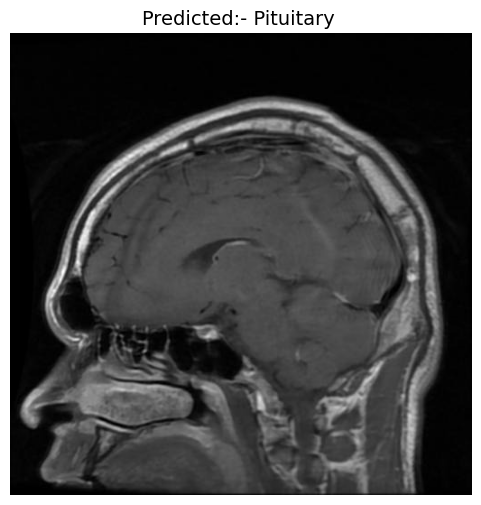

In [11]:
import matplotlib.pyplot as plt

# Path of a single image
image_path = r"data_merged\test\pituitary\f6346cc85d2e6661bd1c8fc0f9ddf794c359bcf7d9602942430fe1263f1d53a4.jpg"

# Predict
result = predict_image(image_path, topk=1)

# Handle different return structures
first_result = result[0]
if isinstance(first_result, (list, tuple)) and len(first_result) == 2:
    pred_label, pred_prob = first_result
else:
    pred_label, pred_prob = str(first_result), 0.0  # fallback

# Open and plot the image
img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted:- {pred_label.capitalize()} ", fontsize=14)
plt.show()
